# Problema 6: Comparación entre el Kernel Laplaciano y el algoritmo Canny para detección de bordes

La detección de bordes es una técnica utilizada en procesamiento digital de imágenes para
identificar regiones donde existe un cambio significativo de intensidad entre píxeles vecinos.

Los bordes representan los límites de los objetos dentro de una imagen y son utilizados en
aplicaciones como reconocimiento de objetos, segmentación, visión artificial y análisis
de imágenes.

En este problema se comparan dos métodos utilizados para la detección de bordes:

- Filtro Laplaciano.
- Algoritmo de Canny.

## Kernel Laplaciano

El filtro Laplaciano es un operador basado en la segunda derivada espacial de una imagen.

Su objetivo es encontrar regiones donde la intensidad cambia rápidamente, ya que estos
cambios representan posibles bordes.

A diferencia de otros filtros, el Laplaciano no calcula la dirección del borde, sino que
detecta cambios de intensidad independientemente de la orientación.

Algunos kernels utilizados son:

\[
\begin{bmatrix}
0 & -1 & 0\\
-1 & 4 & -1\\
0 & -1 & 0
\end{bmatrix}
\]

y

\[
\begin{bmatrix}
-1 & -1 & -1\\
-1 & 8 & -1\\
-1 & -1 & -1
\end{bmatrix}
\]

Una desventaja del Laplaciano es que utiliza la segunda derivada, por lo que es muy
sensible al ruido presente en la imagen. Por esta razón normalmente se recomienda aplicar
un suavizado previo, como un filtro Gaussiano.

## Algoritmo Canny

El detector de bordes Canny es un método más avanzado que combina diferentes etapas para
obtener bordes más definidos y reducir la cantidad de falsos positivos.

Las etapas principales son:

1. Suavizado Gaussiano:
   Reduce el ruido antes de detectar bordes.

2. Cálculo del gradiente:
   Determina la intensidad y dirección del cambio utilizando derivadas.

3. Supresión de máximos no locales:
   Reduce los bordes gruesos conservando únicamente los píxeles más representativos.

4. Doble umbral:
   Clasifica los bordes en fuertes y débiles.

5. Histéresis:
   Conecta los bordes débiles relacionados con bordes fuertes.

Debido a este proceso, Canny suele producir resultados más limpios y precisos que un filtro
Laplaciano aplicado directamente.

## Diferencias principales entre Laplaciano y Canny

| Característica | Laplaciano | Canny |
|---|---|---|
| Tipo de operación | Segunda derivada | Varias etapas de procesamiento |
| Sensibilidad al ruido | Alta | Baja debido al suavizado |
| Dirección del borde | No calcula dirección | Utiliza dirección del gradiente |
| Resultado | Puede generar muchos bordes falsos | Bordes más definidos |
| Complejidad | Baja | Mayor |
| Uso común | Análisis rápido de cambios de intensidad | Sistemas de visión artificial |

En conclusión, el filtro Laplaciano es un método sencillo y rápido para encontrar cambios
de intensidad, mientras que Canny es un algoritmo más robusto diseñado para obtener bordes
más precisos en imágenes reales.

Imagen utilizada: C:\Users\luisi\Documents\Maestria BI\Analisis de datos\Text Mining & Image Recognition\Lab2\Imagenes lab\1.jpg
Imagen cargada correctamente


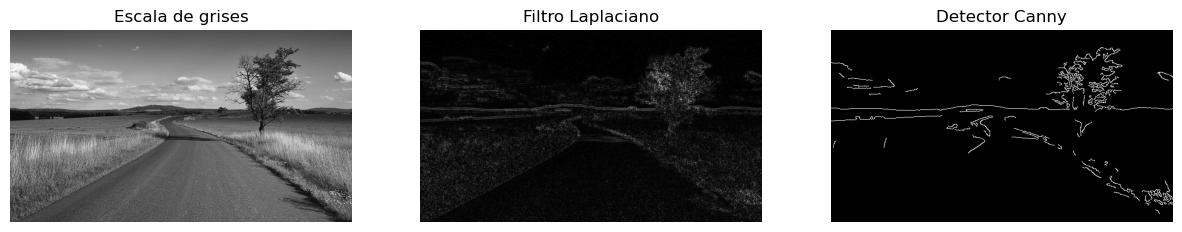

In [2]:
import os
import cv2
import matplotlib.pyplot as plt


ruta_carpeta = r"C:\Users\luisi\Documents\Maestria BI\Analisis de datos\Text Mining & Image Recognition\Lab2\Imagenes lab"


# Seleccionar imagen 1 automáticamente
archivo = [x for x in os.listdir(ruta_carpeta) if x.startswith("1")][0]


ruta = os.path.join(ruta_carpeta, archivo)


print("Imagen utilizada:", ruta)


# Leer imagen
imagen = cv2.imread(ruta)


# Validación
if imagen is None:
    print("No se pudo cargar la imagen")
else:
    print("Imagen cargada correctamente")


# Escala de grises
gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)


# Suavizado Gaussiano
suavizada = cv2.GaussianBlur(gris,(5,5),0)


# Laplaciano
laplaciano = cv2.Laplacian(suavizada, cv2.CV_64F)
laplaciano = cv2.convertScaleAbs(laplaciano)


# Canny
canny = cv2.Canny(suavizada,100,200)


# Mostrar
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gris,cmap="gray")
plt.title("Escala de grises")
plt.axis("off")


plt.subplot(1,3,2)
plt.imshow(laplaciano,cmap="gray")
plt.title("Filtro Laplaciano")
plt.axis("off")


plt.subplot(1,3,3)
plt.imshow(canny,cmap="gray")
plt.title("Detector Canny")
plt.axis("off")


plt.show()

## Interpretación

Al comparar ambos métodos se observa que el filtro Laplaciano detecta cambios de intensidad
en diferentes zonas de la imagen, pero puede generar bordes adicionales debido al ruido.

Por otro lado, Canny produce bordes más delgados y definidos gracias a las etapas de
filtrado, supresión y umbralización.

Por esta razón, aunque el filtro Laplaciano es más simple y rápido, el algoritmo Canny suele
ser preferido en aplicaciones donde se necesita una detección de bordes más precisa.